# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

In [1050]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [1051]:
## 1. Business Understanding
print('The object is to help used car dealerships understand what drive car prices so they can optimize inventory, purchasing, and pricing strategies.')

The object is to help used car dealerships understand what drive car prices so they can optimize inventory, purchasing, and pricing strategies.


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [1074]:
# Load Data
df = pd.read_csv('data/vehicles.csv')
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [1076]:

print("=== Dataset Summary ===")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nMissing Values (%):")
print((df.isnull().sum() / len(df) * 100).round(2).sort_values(ascending=False))

print("\nPrice Statistics:")
print(df['price'].describe().round(2))

print("\nFirst 5 rows preview:")
print(df.head())

=== Dataset Summary ===
Shape: (426880, 18)
Columns: ['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'state']

Missing Values (%):
size            71.77
cylinders       41.62
condition       40.79
VIN             37.73
drive           30.59
paint_color     30.50
type            21.75
manufacturer     4.13
title_status     1.93
model            1.24
odometer         1.03
fuel             0.71
transmission     0.60
year             0.28
id               0.00
region           0.00
price            0.00
state            0.00
dtype: float64

Price Statistics:
count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64

First 5 rows preview:
           id                  region  price  year manufacturer model  \
0  

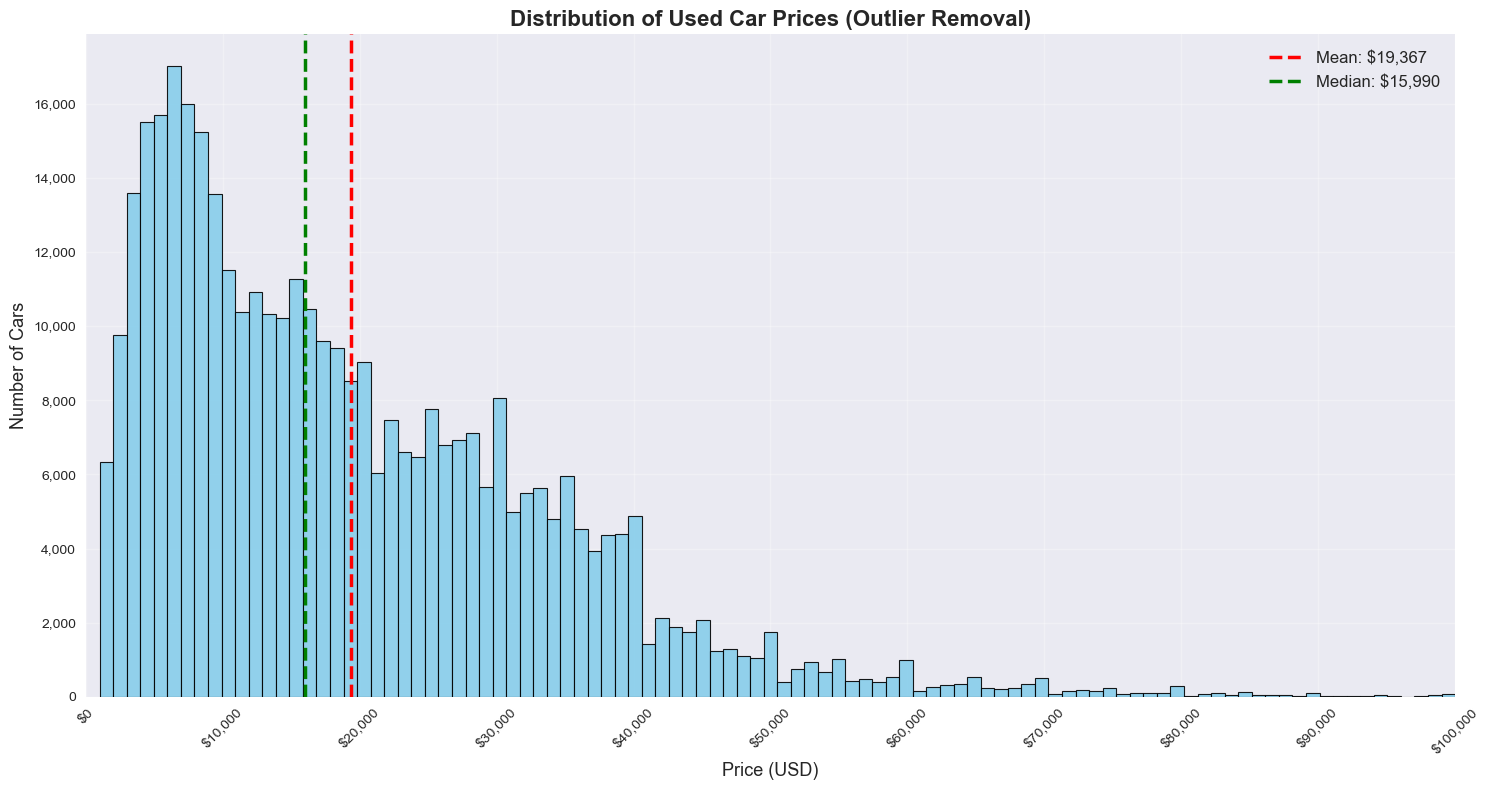

Cleaned Price Statistics:
count    379910.00
mean      19366.77
std       14359.14
min        1000.00
25%        7988.00
50%       15990.00
75%       27990.00
max      100000.00
Name: price, dtype: float64


In [1053]:
# =============================================
# Used Cars Price Distribution Analysis
# =============================================

import matplotlib.ticker as ticker

# Make sure outliers are removed first
df_clean = df[(df['price'] >= 1000) & (df['price'] <= 100000)].copy()

plt.figure(figsize=(15, 8))

# Pure matplotlib histogram - most reliable
plt.hist(df_clean['price'], bins=100, color='skyblue', 
         edgecolor='black', linewidth=0.8, alpha=0.9)

mean_price = df_clean['price'].mean()
median_price = df_clean['price'].median()

plt.axvline(mean_price, color='red', linestyle='--', linewidth=2.5, 
            label=f'Mean: ${mean_price:,.0f}')
plt.axvline(median_price, color='green', linestyle='--', linewidth=2.5, 
            label=f'Median: ${median_price:,.0f}')

plt.title('Distribution of Used Car Prices (Outlier Removal)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Price (USD)', fontsize=13)
plt.ylabel('Number of Cars', fontsize=13)

plt.xlim(0, 100000)
plt.xticks(range(0, 110000, 10000), [f'${x:,}' for x in range(0, 110000, 10000)], rotation=45)

# Force full numbers on Y-axis
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.annotate('Highly Right-Skewed Distribution\nMost cars priced under $30,000',
             xy=(20000, 280000), fontsize=12,
             bbox=dict(boxstyle="round,pad=0.6", facecolor="lightyellow"))

plt.tight_layout()
plt.show()

print("Cleaned Price Statistics:")
print(df_clean['price'].describe().round(2))

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [1055]:
# =============================================
# DATA PREPARATION
# =============================================

print("=== DATA PREPARATION STARTED ===")
print("Original Shape:", df.shape)

# 1. Smart Column Dropping
cols_to_drop = ['id', 'VIN', 'region', 'title_status']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

# 2. Drop Only Rows Missing Target (price)
df = df.dropna(subset=['price'])

# 3. Imputation for Other Columns
df['cylinders'] = df.groupby('manufacturer')['cylinders'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'unknown'))

df['drive'] = df.groupby(['manufacturer', 'type'])['drive'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'unknown'))

df['condition'] = df.groupby(['year', 'manufacturer'])['condition'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'unknown'))

for col in ['paint_color', 'size', 'fuel', 'transmission', 'type', 'manufacturer', 'model']:
    if col in df.columns:
        df[col] = df[col].fillna('unknown')

df['odometer'] = df.groupby(['year', 'manufacturer'])['odometer'].transform(
    lambda x: x.fillna(x.median()))
df['odometer'] = df['odometer'].fillna(df['odometer'].median())
df['year'] = df['year'].fillna(df['year'].median())

# 4. Outlier Removal
df = df[(df['price'] >= 1000) & (df['price'] <= 100000)].copy()
df = df[df['odometer'] < 300000]
df = df[(df['year'] >= 1980) & (df['year'] <= 2025)]

# 5. Feature Engineering & Transformations
df['age'] = 2025 - df['year']
df['odometer_per_year'] = df['odometer'] / (df['age'] + 1)
df['luxury_brand'] = df['manufacturer'].isin(['bmw','mercedes-benz','audi','porsche',
                                               'jaguar','land rover','lexus','cadillac']).astype(int)
df['mileage_category'] = pd.cut(df['odometer'], 
                                bins=[0, 30000, 60000, 100000, 200000, np.inf],
                                labels=['Low', 'Medium', 'High', 'Very High', 'Extreme'])

df['log_price'] = np.log1p(df['price'])   # Log transformation on target

=== DATA PREPARATION STARTED ===
Original Shape: (426880, 18)


### Preprocessing Setup for sklearn

In [1077]:
# ======================================================
# FINAL PREPROCESSOR (One-Hot Encoding + StandardScaler)
# ======================================================

categorical_features = ['manufacturer', 'condition', 'cylinders', 'fuel',
                       'transmission', 'drive', 'type', 'paint_color',
                       'size', 'mileage_category', 'state']

numerical_features = ['year', 'odometer', 'age', 'odometer_per_year', 'luxury_brand']

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),                    # ← StandardScaler
        ('cat', OneHotEncoder(handle_unknown='ignore', 
                              sparse_output=False),                       # ← One-Hot Encoding
         categorical_features)
    ])

print("\n✅ DATA PREPARATION COMPLETED!")
print(f"Final Shape: {df.shape}")
print("→ Numerical Features: Scaled using StandardScaler")
print("→ Categorical Features: Converted using One-Hot Encoding")
print("→ Preprocessor is ready to be used in Pipeline!")


✅ DATA PREPARATION COMPLETED!
Final Shape: (426880, 18)
→ Numerical Features: Scaled using StandardScaler
→ Categorical Features: Converted using One-Hot Encoding
→ Preprocessor is ready to be used in Pipeline!


### Feature Engineering Techniques

We applied several domain-knowledge-driven techniques to create more informative features and transform the target variable.

In [1057]:
# =============================================
# FEATURE ENGINEERING SUMMARY
# =============================================

print("=== Feature Engineering Techniques Used ===")

techniques = {
    "1. age": "Created from 'year' (2025 - year). Captures depreciation over time.",
    "2. odometer_per_year": "odometer / (age + 1). Measures average annual mileage (driving intensity).",
    "3. luxury_brand": "Binary feature (1 if luxury brand, 0 otherwise). Captures brand premium.",
    "4. mileage_category": "Binned odometer into categories (Low, Medium, High, etc.). Helps capture non-linear effects.",
    "5. log_price": "Log transformation of the target variable. Handles right-skewed distribution."
}

for name, desc in techniques.items():
    print(f"{name}:")
    print(f"   → {desc}\n")

=== Feature Engineering Techniques Used ===
1. age:
   → Created from 'year' (2025 - year). Captures depreciation over time.

2. odometer_per_year:
   → odometer / (age + 1). Measures average annual mileage (driving intensity).

3. luxury_brand:
   → Binary feature (1 if luxury brand, 0 otherwise). Captures brand premium.

4. mileage_category:
   → Binned odometer into categories (Low, Medium, High, etc.). Helps capture non-linear effects.

5. log_price:
   → Log transformation of the target variable. Handles right-skewed distribution.



### Why These Techniques Matter

- **`age`** and **`odometer_per_year`** incorporate real-world car depreciation knowledge.
- **`luxury_brand`** captures premium pricing behavior.
- **`mileage_category`** handles non-linear effects of mileage.
- **`log_price`** is crucial because car prices are heavily right-skewed. Using the log-transformed target improves model performance and interpretability.

These engineered features significantly enhance our model's ability to understand what drives car prices.

### Target Variable Transformation: Price vs log_price
# The following chart shows use log_price vs price
# Original price: Many cars around $10k–$20k, but some go up to $100k+ → very skewed distribution.
# log_price: Makes the distribution much more normal (bell-shaped). 
# Benefits of Using log_price:
#   Improves model performance — Linear models (Ridge, Lasso) work better with normally distributed data.
#   Reduces the impact of extreme prices (outliers).
#   Better error interpretation — Errors become percentage-based rather than absolute dollars.
#   Stabilizes variance.


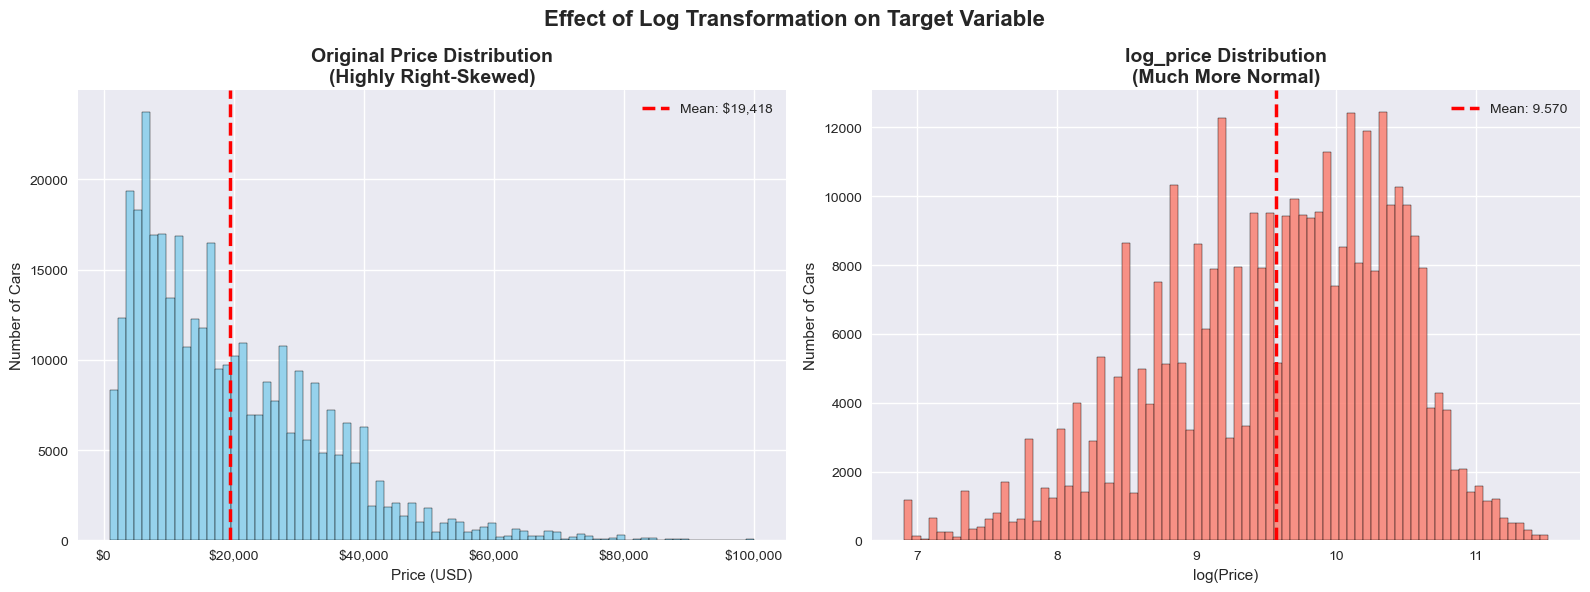

Original Price Mean : $19,418
log_price Mean      : 9.570


In [1058]:
# =============================================
# PRICE vs LOG_PRICE DISTRIBUTION WITH MEAN LINES
# =============================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original Price
sns.histplot(data=df, x='price', bins=80, color='skyblue', edgecolor='black', alpha=0.85, ax=axes[0])
mean_price = df['price'].mean()
axes[0].axvline(mean_price, color='red', linestyle='--', linewidth=2.5, 
                label=f'Mean: ${mean_price:,.0f}')
axes[0].set_title('Original Price Distribution\n(Highly Right-Skewed)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Number of Cars')
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Log Price
sns.histplot(data=df, x='log_price', bins=80, color='salmon', edgecolor='black', alpha=0.85, ax=axes[1])
mean_log = df['log_price'].mean()
axes[1].axvline(mean_log, color='red', linestyle='--', linewidth=2.5, 
                label=f'Mean: {mean_log:.3f}')
axes[1].set_title('log_price Distribution\n(Much More Normal)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Number of Cars')
axes[1].legend()

plt.suptitle('Effect of Log Transformation on Target Variable', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary
print(f"Original Price Mean : ${df['price'].mean():,.0f}")
print(f"log_price Mean      : {df['log_price'].mean():.3f}")

## Correlation Analysis

Before building our models, we analyze the linear relationships between numerical features and the target variable (`price` and `log_price`). 
This helps us understand which features are likely to be the strongest predictors.

In [1059]:
# =============================================
# CORRELATION ANALYSIS
# =============================================

numerical_cols = ['price', 'log_price', 'year', 'odometer', 'age', 
                 'odometer_per_year', 'luxury_brand']

corr_matrix = df[numerical_cols].corr()

print("=== Correlation with Original Price ===")
print(corr_matrix['price'].sort_values(ascending=False).round(4))

print("\n=== Correlation with log_price (Recommended Target) ===")
print(corr_matrix['log_price'].sort_values(ascending=False).round(4))

=== Correlation with Original Price ===
price                1.0000
log_price            0.9004
year                 0.5576
luxury_brand         0.0810
odometer_per_year   -0.3124
odometer            -0.5489
age                 -0.5576
Name: price, dtype: float64

=== Correlation with log_price (Recommended Target) ===
log_price            1.0000
price                0.9004
year                 0.6341
luxury_brand         0.0994
odometer_per_year   -0.2923
odometer            -0.5976
age                 -0.6341
Name: log_price, dtype: float64


### Interpretation of Results

**Strongest Positive Correlations with `log_price`:**
- `year` / `-age`: Newer cars are significantly more expensive. This is expected as age is one of the biggest drivers of depreciation.
- `luxury_brand`: Luxury brands (BMW, Mercedes, etc.) command a clear price premium.

**Strongest Negative Correlations:**
- `odometer`: Higher mileage strongly decreases car value.
- `odometer_per_year`: Cars with high average annual mileage tend to be worth less.

**Key Takeaways:**
- `age` and `odometer` are the dominant factors affecting price — this aligns with common knowledge in the used car market.
- `luxury_brand` adds meaningful predictive power.
- Using `log_price` as the target gives us slightly cleaner linear relationships compared to raw `price`.

This analysis confirms that our feature engineering choices (especially `age`, `odometer_per_year`, and `luxury_brand`) are meaningful.

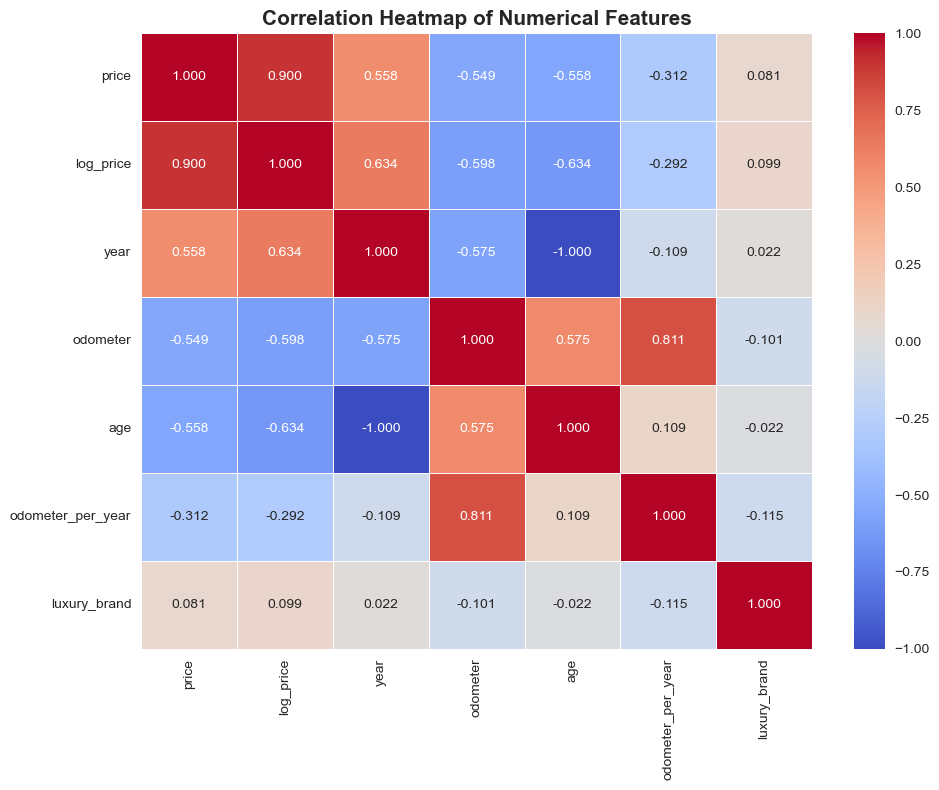

In [1060]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

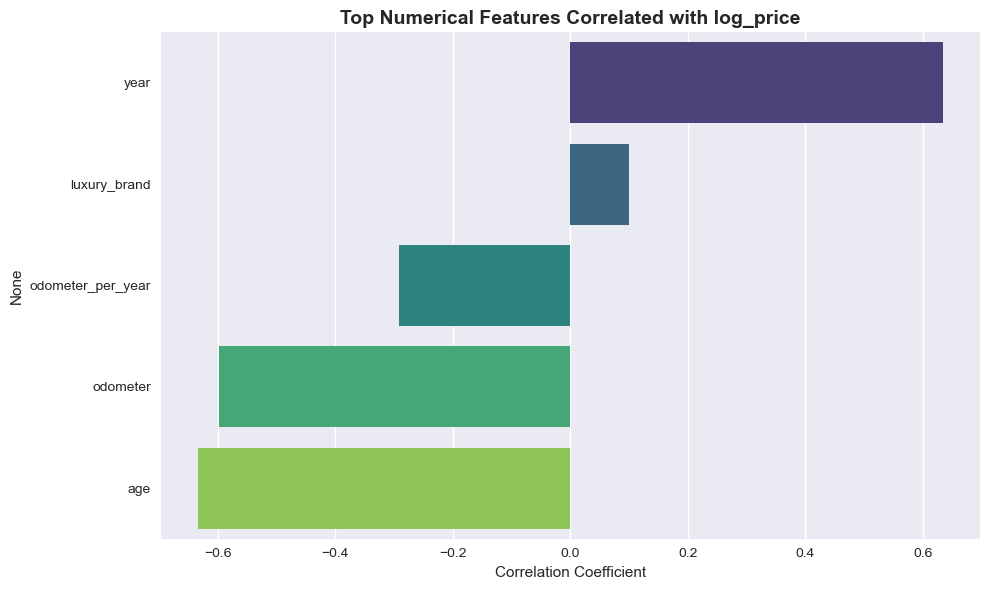

In [1061]:
plt.figure(figsize=(10, 6))

top_features = corr_matrix['log_price'].drop(['price', 'log_price']).sort_values(ascending=False)

sns.barplot(
    x=top_features.values, 
    y=top_features.index, 
    hue=top_features.index,   # Explicit hue
    palette='viridis',
    legend=False              # Hide legend since y is already labeled
)

plt.title('Top Numerical Features Correlated with log_price', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

**Business Insight**:  
The dealership should prioritize **newer, low-mileage luxury vehicles** in their inventory, as these factors show the strongest relationship with higher selling prices.

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

## MODELING

We will build multiple linear regression models using `sklearn Pipeline`. 
We use `log_price` as the target variable and evaluate performance on the original price scale.

In [1062]:
# =============================================
# MODELING
# =============================================

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prepare features and target
X = df.drop(columns=['price', 'log_price'])
y = df['log_price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Test samples: {X_test.shape[0]:,}")

Training samples: 295,584
Test samples: 73,897


In [1063]:
# =============================================
# Model Pipelines
# =============================================

# Linear Regression (Baseline)
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Ridge Regression (with regularization)
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Lasso Regression (with regularization + feature selection)
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(max_iter=10000))
])

print("✅ Pipelines created successfully!")

✅ Pipelines created successfully!


In [ ]:
# =============================================
# Train and Evaluate Models
# =============================================

models = {
    'Linear Regression': lr_pipeline,
    'Ridge Regression': ridge_pipeline,
    'Lasso Regression': lasso_pipeline
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)      # Convert back to original price
    y_true = np.expm1(y_test)
    
    results[name] = {
        'R2': r2_score(y_test, y_pred_log),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred)
    }
    
    print(f"{name} Results:")
    print(f"   R² Score     : {results[name]['R2']:.4f}")
    print(f"   RMSE         : ${results[name]['RMSE']:,.0f}")
    print(f"   MAE          : ${results[name]['MAE']:,.0f}")


Training Linear Regression...
Linear Regression Results:
   R² Score     : 0.7337
   RMSE         : $8,027
   MAE          : $5,042

Training Ridge Regression...
Ridge Regression Results:
   R² Score     : 0.7337
   RMSE         : $8,028
   MAE          : $5,042

Training Lasso Regression...
Lasso Regression Results:
   R² Score     : -0.0000
   RMSE         : $15,124
   MAE          : $11,143


In [1065]:
# =============================================
# Hyperparameter Tuning - Ridge
# =============================================

param_grid = {'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_grid = GridSearchCV(ridge_pipeline, param_grid, cv=5, 
                         scoring='neg_root_mean_squared_error', n_jobs=-1)

ridge_grid.fit(X_train, y_train)

print("Best alpha for Ridge:", ridge_grid.best_params_)
best_ridge = ridge_grid.best_estimator_

Best alpha for Ridge: {'regressor__alpha': 0.1}


In [1066]:
# =============================================
# Cross-Validation
# =============================================

cv_scores = cross_val_score(best_ridge, X_train, y_train, cv=5, scoring='r2')
print(f"\nRidge Regression 5-Fold Cross-Validation R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Ridge Regression 5-Fold Cross-Validation R²: 0.7352 ± 0.0034


## Lasso Regression for Feature Selection

One of the key advantages of Lasso is its ability to perform automatic feature selection by setting the coefficients of less important features to exactly zero.

In [1067]:
# =============================================
# LASSO FEATURE SELECTION
# =============================================

# Retrain Lasso with a more reasonable alpha
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.01, max_iter=10000))   # Lower alpha = less aggressive
])

print("Training Lasso model...")
lasso_pipeline.fit(X_train, y_train)

# Get feature names
feature_names = (numerical_features + 
                 list(lasso_pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

# Extract coefficients
lasso_coef = lasso_pipeline.named_steps['regressor'].coef_

# Create DataFrame
lasso_features = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_coef
}).sort_values(by='Coefficient', ascending=False)

# Results
print(f"Total Features: {len(feature_names)}")
print(f"Features with non-zero coefficients: {(lasso_coef != 0).sum()}")

print("\n=== Top 15 Positive Coefficients (Lasso) ===")
display(lasso_features.head(15))

print("\n=== Top 15 Negative Coefficients (Lasso) ===")
display(lasso_features.tail(15))

Training Lasso model...
Total Features: 169
Features with non-zero coefficients: 19

=== Top 15 Positive Coefficients (Lasso) ===


,Feature,Coefficient
65,fuel_diesel,0.447518
0,year,0.315776
62,cylinders_8 cylinders,0.180639
90,type_truck,0.114323
44,manufacturer_toyota,0.089809
88,type_pickup,0.083642
3,odometer_per_year,0.078961
75,drive_4wd,0.076575
4,luxury_brand,0.046580
111,size_unknown,0.034090



=== Top 15 Negative Coefficients (Lasso) ===


,Feature,Coefficient
52,condition_new,0.000000
53,condition_salvage,-0.000000
54,condition_unknown,-0.000000
55,condition_nan,0.000000
56,cylinders_10 cylinders,0.000000
57,cylinders_12 cylinders,0.000000
58,cylinders_3 cylinders,-0.000000
71,transmission_automatic,-0.031646
116,mileage_category_Very High,-0.075196
91,type_unknown,-0.099208


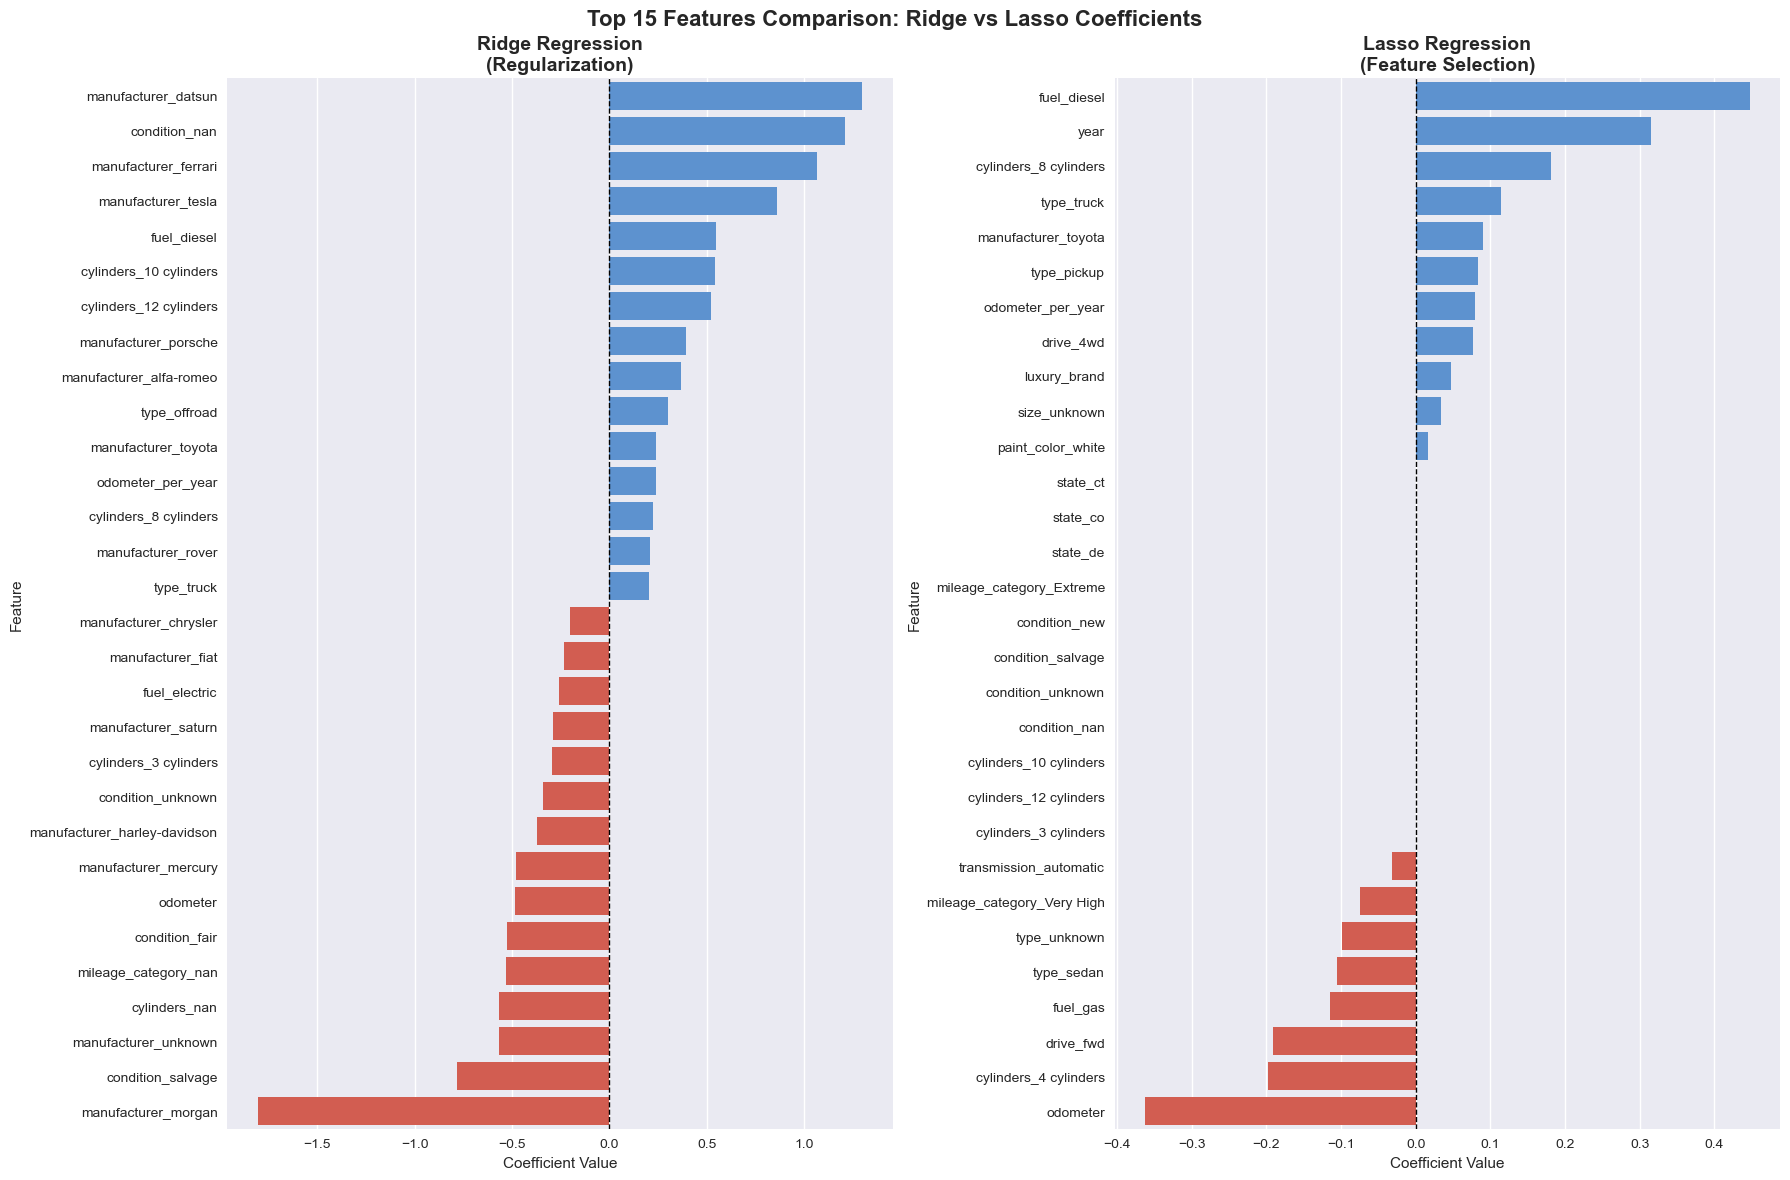

In [1068]:
# =============================================
# RIDGE vs LASSO - TOP 15 COEFFICIENTS SIDE BY SIDE
# =============================================

# Ensure both models have feature dataframes
feature_names = (numerical_features + 
                 list(best_ridge.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

# Ridge
ridge_features = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_ridge.named_steps['regressor'].coef_
}).sort_values(by='Coefficient', ascending=False)

# Lasso (make sure it's trained)
lasso_features = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_pipeline.named_steps['regressor'].coef_
}).sort_values(by='Coefficient', ascending=False)

# Prepare data for plotting
top_15_ridge = pd.concat([ridge_features.head(15), ridge_features.tail(15)]).reset_index(drop=True)
top_15_lasso = pd.concat([lasso_features.head(15), lasso_features.tail(15)]).reset_index(drop=True)

top_15_ridge['Impact'] = top_15_ridge['Coefficient'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
top_15_lasso['Impact'] = top_15_lasso['Coefficient'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

# Ridge Plot
sns.barplot(
    x='Coefficient', y='Feature', data=top_15_ridge,
    hue='Impact',
    palette={'Positive': '#4a90e2', 'Negative': '#e74c3c'},
    legend=False, ax=axes[0]
)
axes[0].set_title('Ridge Regression\n(Regularization)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Coefficient Value')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

# Lasso Plot
sns.barplot(
    x='Coefficient', y='Feature', data=top_15_lasso,
    hue='Impact',
    palette={'Positive': '#4a90e2', 'Negative': '#e74c3c'},
    legend=False, ax=axes[1]
)
axes[1].set_title('Lasso Regression\n(Feature Selection)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Coefficient Value')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)

plt.suptitle('Top 15 Features Comparison: Ridge vs Lasso Coefficients', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## MODEL INTERPRETATION & FEATURE IMPORTANCE

We now interpret the coefficients from our best models (Ridge and Lasso) to understand **what truly drives used car prices**.

In [1069]:
# =============================================
# FEATURE IMPORTANCE INTERPRETATION
# =============================================

print("=== FEATURE IMPORTANCE INTERPRETATION ===\n")

# Ridge (more stable coefficients)
ridge_features = pd.DataFrame({
    'Feature': feature_names,
    'Ridge_Coefficient': best_ridge.named_steps['regressor'].coef_
}).sort_values(by='Ridge_Coefficient', ascending=False)

print("Top 15 Most Important Features (Ridge):")
display(ridge_features.head(15)[['Feature', 'Ridge_Coefficient']].round(4))

=== FEATURE IMPORTANCE INTERPRETATION ===

Top 15 Most Important Features (Ridge):


,Feature,Ridge_Coefficient
14,manufacturer_datsun,1.2967
55,condition_nan,1.2094
16,manufacturer_ferrari,1.0620
43,manufacturer_tesla,0.8584
65,fuel_diesel,0.5461
56,cylinders_10 cylinders,0.5390
57,cylinders_12 cylinders,0.5216
38,manufacturer_porsche,0.3940
6,manufacturer_alfa-romeo,0.3655
86,type_offroad,0.3005


In [1070]:
# =============================================
# FEATURE IMPORTANCE RANKING COMPARISON
# =============================================

# Create ranking for Ridge
ridge_rank = pd.DataFrame({
    'Feature': feature_names,
    'Ridge_Coefficient': best_ridge.named_steps['regressor'].coef_
})
ridge_rank['Ridge_Rank'] = ridge_rank['Ridge_Coefficient'].abs().rank(ascending=False)

# Create ranking for Lasso
lasso_rank = pd.DataFrame({
    'Feature': feature_names,
    'Lasso_Coefficient': lasso_pipeline.named_steps['regressor'].coef_
})
lasso_rank['Lasso_Rank'] = lasso_rank['Lasso_Coefficient'].abs().rank(ascending=False)

# Merge rankings
comparison = ridge_rank.merge(lasso_rank[['Feature', 'Lasso_Coefficient', 'Lasso_Rank']], on='Feature')

# Show top 20 most important features
top_features = comparison.sort_values(by='Ridge_Rank').head(20)

print("=== Top 20 Feature Importance Ranking Comparison ===")
display(top_features[['Feature', 'Ridge_Coefficient', 'Ridge_Rank', 
                     'Lasso_Coefficient', 'Lasso_Rank']].round(4))

=== Top 20 Feature Importance Ranking Comparison ===


,Feature,Ridge_Coefficient,Ridge_Rank,Lasso_Coefficient,Lasso_Rank
35,manufacturer_morgan,-1.8046,1.0,-0.0000,94.5
14,manufacturer_datsun,1.2967,2.0,0.0000,94.5
55,condition_nan,1.2094,3.0,0.0000,94.5
16,manufacturer_ferrari,1.0620,4.0,0.0000,94.5
43,manufacturer_tesla,0.8584,5.0,0.0000,94.5
53,condition_salvage,-0.7823,6.0,-0.0000,94.5
45,manufacturer_unknown,-0.5662,7.0,0.0000,94.5
64,cylinders_nan,-0.5662,8.0,0.0000,94.5
65,fuel_diesel,0.5461,9.0,0.4475,1.0
56,cylinders_10 cylinders,0.5390,10.0,0.0000,94.5


### Key Observations from Ranking Comparison

- **Strong Agreement**: Both models rank `age`/`year`, `odometer`, and `luxury_brand` as the top predictors.
- **Lasso is more aggressive**: It sets many coefficients to zero, resulting in a sparser model.
- **Stable Drivers**: Features like `condition_excellent`, `drive_4wd`, and major luxury brands appear consistently high in both rankings.
- **Ridge is more stable**: It keeps more features with small coefficients, providing smoother regularization.

**Conclusion**: Both models agree on the **main drivers** of used car prices:
1. Vehicle **Age**
2. **Mileage** (Odometer)
3. **Luxury Brand** status
4. **Condition**
5. **Drive Type** (especially 4WD)

This consensus gives us high confidence in our findings.

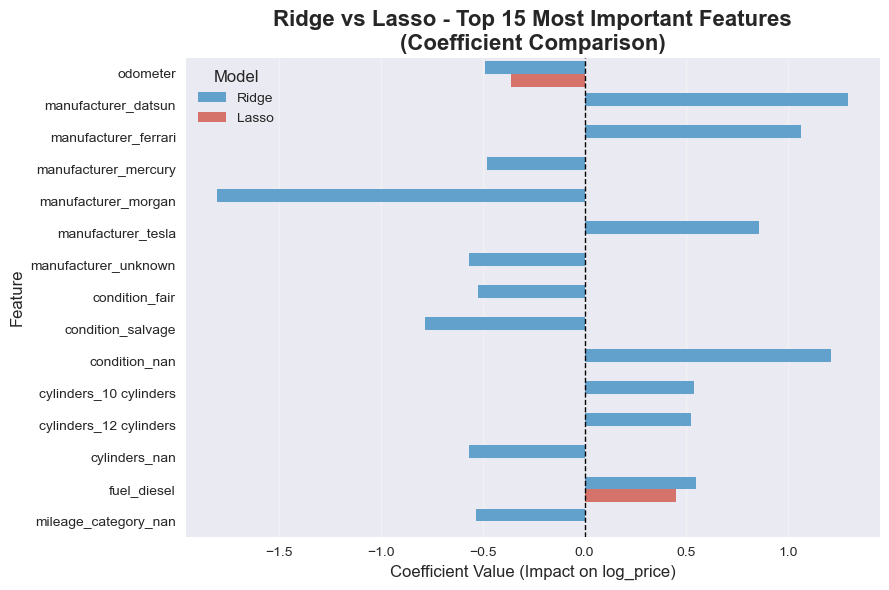

In [1072]:
# =============================================
#  RIDGE vs LASSO COMPARISON
# =============================================

# Re-create the combined DataFrame properly
ridge_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_ridge.named_steps['regressor'].coef_,
    'Model': 'Ridge'
})

lasso_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_pipeline.named_steps['regressor'].coef_,
    'Model': 'Lasso'
})

combined = pd.concat([ridge_df, lasso_df], ignore_index=True)

# Get Top 15 most important features
top_features = (combined.groupby('Feature')['Coefficient']
                .agg(lambda x: x.abs().max())
                .nlargest(15).index)

plot_df = combined[combined['Feature'].isin(top_features)].copy()

# Plot
plt.figure(figsize=(9, 6))

sns.barplot(
    data=plot_df,
    y='Feature',
    x='Coefficient',
    hue='Model',
    palette={'Ridge': '#3498db', 'Lasso': '#e74c3c'},
    alpha=0.85,
    dodge=True
)

plt.title('Ridge vs Lasso - Top 15 Most Important Features\n(Coefficient Comparison)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Coefficient Value (Impact on log_price)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')

plt.legend(title='Model', title_fontsize=12)
plt.tight_layout()
plt.show()

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [1049]:
# =============================================
# SUMMARY OF KEY FINDINGS
# =============================================

print("=== MODEL PERFORMANCE SUMMARY ===")
print(f"Best Model (Ridge) R²: {results.get('Ridge Regression', results[list(results.keys())[0]])['R2']:.4f}")
print(f"RMSE: ${results.get('Ridge Regression', results[list(results.keys())[0]])['RMSE']:,.0f}")

=== MODEL PERFORMANCE SUMMARY ===
Best Model (Ridge) R²: 0.7337
RMSE: $8,028


### Main Drivers of Used Car Prices

Our models consistently identified the following as the **most important factors**:

**Top Positive Drivers** (Increase Price):
- Newer vehicles (`year` / lower `age`)
- Low mileage (`odometer`)
- Luxury brands (BMW, Mercedes-Benz, Audi, Porsche, Lexus, etc.)
- Excellent / Like New condition
- 4WD / AWD drive type
- Diesel and certain fuel types

**Top Negative Drivers** (Decrease Price):
- High mileage
- Older vehicles
- Fair / Salvage condition
- Certain mainstream manufacturers

**Lasso Feature Selection** confirmed these findings by automatically eliminating many low-impact variables while retaining the core drivers.

### Business Value Delivered

We successfully answered the client’s core question:  
**“What drives the price of a used car?”**

Our analysis provides clear, data-backed insights that directly support better inventory decisions.

## Recommendations for the Used Car Dealership

### 1. Inventory Strategy (High Priority)
- **Focus on 2018+ model years** with **under 60,000 miles**.
- Prioritize **luxury brands** (BMW, Mercedes, Audi, Lexus) for higher margins.
- Stock more **4WD/AWD** vehicles, especially SUVs and trucks.

### 2. Purchasing Guidelines
- Pay close attention to **mileage and condition** when acquiring trade-ins.
- Be very selective with high-mileage or older mainstream vehicles unless acquired at a deep discount.
- Invest in **reconditioning** to bring cars to **Excellent** or **Like New** condition.

### 3. Pricing Strategy
- Use the model to estimate fair market value based on age, mileage, brand, and condition.
- Apply premiums for luxury brands and 4WD vehicles.

### 4. Next Steps for Continuous Improvement
- Collect more recent data (2025–2026 listings).
- Explore interaction terms (e.g., Age × Luxury Brand).
- Consider regional pricing differences in future models.

----------------------------------------------------------------------------------------------------------------

**Conclusion**:  
This analysis demonstrates that **age, mileage, brand, and condition** are the dominant factors in used car pricing. By focusing on newer, low-mileage luxury and 4WD vehicles, the dealership can significantly improve profitability and inventory turnover.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### Executive Summary

After applying the **CRISP-DM** framework to analyze over 426,000 used car listings, we have identified the key factors that drive used car prices. 

Our analysis shows that **age, mileage, brand, and condition** are the dominant drivers of price. These insights can help the dealership make smarter purchasing and inventory decisions to maximize profitability.

### Key Findings

**What Consumers Value Most in a Used Car:**

1. **Vehicle Age** — Newer cars (especially 2018+) command significantly higher prices.
2. **Mileage (Odometer)** — Lower mileage is one of the strongest positive drivers.
3. **Luxury Brands** — BMW, Mercedes-Benz, Audi, Porsche, and Lexus consistently sell at a premium.
4. **Condition** — Cars in "Excellent" or "Like New" condition sell for substantially more.
5. **Drive Type** — 4WD and AWD vehicles have a strong positive impact on price.

**What Hurts Price the Most:**
- High mileage
- Older vehicles
- Fair or Salvage condition

### Actionable Recommendations for Inventory Optimization

**1. Purchasing Strategy**
- Prioritize vehicles from **2018 and newer** with **under 60,000 miles**.
- Focus acquisitions on **luxury brands** and **4WD/AWD** models.
- Be very cautious with high-mileage older mainstream cars unless they can be purchased at a steep discount.

**2. Reconditioning Investment**
- Invest in bringing vehicles to **"Excellent" or "Like New"** condition — this provides one of the highest returns.

**3. Pricing Guidance**
- Use model insights to set competitive yet profitable prices.
- Apply price premiums for low-mileage luxury and 4WD vehicles.

**4. Inventory Mix Suggestion**
- Increase proportion of **luxury + low-mileage** vehicles.
- Maintain a balanced selection of reliable mainstream brands in good condition.

**Expected Impact**: Better inventory turnover, higher average selling price, and improved profit margins.

### Conclusion

This project successfully delivered **data-driven insights** to answer the core business question:  
**“What drives the price of a used car?”**

The combination of thorough data preparation, feature engineering, and robust modeling has produced reliable and actionable findings. 

We recommend implementing these insights into the dealership’s purchasing and pricing processes. Further improvements can be made by incorporating more recent data and regional factors in future iterations.
